In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Numerosity Data Reduction

### Random Sampling

In [2]:
customer_df = pd.read_csv('Customer Churn.csv')
customer_df.head(3)

,Call Failure,Complains,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Status,Churn
0,8,0,38,4370,71,5,17,1,0
1,0,0,39,318,5,7,4,0,0
2,10,0,37,2453,60,359,24,1,0


In [3]:
customer_df.shape

(3150, 9)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [5]:
y = customer_df['Churn']
#X = customer_df[customer_df['Churn']==False]
X = customer_df.drop(columns='Churn')

In [6]:
# Decision tree model without sampling
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[10,20,30,40,50,60],
    'min_samples_split': [10,20,30,40,50],
    'min_impurity_decrease': [0,0.001,0.005, 0.01, 0.05, 1]}

gridSearch = GridSearchCV(DecisionTreeClassifier(),
                          param_grid,
                          cv=3,
                          scoring='recall',
                          verbose=1).fit(X,y)
print('Best score: ', gridSearch.best_score_)
print('Best parameters: ', gridSearch.best_params_)


Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best score:  0.7353535353535353
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'min_impurity_decrease': 0.005, 'min_samples_split': 40}


In [7]:
# Decision tree model with sampling
customer_df_rs = customer_df.sample(1000, random_state=1)
y = customer_df_rs['Churn']
X = customer_df_rs.drop(columns='Churn')

In [8]:
gridSearch = GridSearchCV(DecisionTreeClassifier(),
                          param_grid,
                          cv=3,
                          scoring='recall',
                          verbose=1).fit(X,y)
print('Best  score: ', gridSearch.best_score_)
print('Best parameters: ', gridSearch.best_params_)

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best  score:  0.7430555555555555
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'min_impurity_decrease': 0.005, 'min_samples_split': 10}


In [9]:
from sklearn.tree import export_graphviz
import graphviz

In [10]:
# Decision tree using best_params_ from sampling above
# Do not use sampling data 
y = customer_df['Churn']
X = customer_df.drop(columns='Churn')

classTree = DecisionTreeClassifier(criterion='entropy',
                                   max_depth=10,
                                   min_samples_split=10,
                                   min_impurity_decrease=0.005).fit(X,y)

dot_data = export_graphviz(classTree,
                           out_file=None,
                           feature_names = X.columns,
                           class_names=['Not Churn',
                                        'Churn'],
                           filled=True,
                           rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render(filename='ChurnDT')

'ChurnDT.pdf'

In [11]:
customer_df['Churn'].value_counts(normalize=True)

Churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

In [12]:
for i in range(3):
    print(customer_df.sample(1000)['Churn'].value_counts(normalize=True))

Churn
0    0.841
1    0.159
Name: proportion, dtype: float64
Churn
0    0.838
1    0.162
Name: proportion, dtype: float64
Churn
0    0.82
1    0.18
Name: proportion, dtype: float64


In [13]:
customer_df_rs['Churn'].value_counts(normalize=True)

Churn
0    0.856
1    0.144
Name: proportion, dtype: float64

### Stratified sampling

In [14]:
n,s = len(customer_df),1000
r=s/n
sample_df = customer_df.groupby('Churn', group_keys=False).apply(lambda sdf: sdf.sample(round(len(sdf)*r)))
print(sample_df['Churn'].value_counts(normalize=True))

Churn
0    0.843
1    0.157
Name: proportion, dtype: float64


In [15]:
customer_df['Churn'].value_counts(normalize=True)

Churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

### Random Over/Undersampling

In [16]:
n,s=len(customer_df),500
sample_df = customer_df.groupby('Churn', group_keys=False).apply(lambda sdf: sdf.sample(250))
print(sample_df.Churn.value_counts(normalize=True))

Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


## Dimensionality Data Reduction

### Linear Regression as a dimension reduction method

In [17]:
amzn_df = pd.read_csv('amznStock.csv')
amzn_df.set_index('t', drop=True, inplace=True)
amzn_df.columns = ['pd_changeP', 'pw_changeP', 'dow_pd_changeP',
       'dow_pw_changeP', 'nasdaq_pd_changeP', 'nasdaq_pw_changeP',
       'changeP']
amzn_df.head(3)

,pd_changeP,pw_changeP,dow_pd_changeP,dow_pw_changeP,nasdaq_pd_changeP,nasdaq_pw_changeP,changeP
t,,,,,,,
2019-08-23,-1.035349,-1.078743,0.188949,-0.105289,-0.333497,-0.268107,-3.049884
2019-08-26,-3.049884,-0.756680,-2.374425,0.586671,-3.145535,-0.335637,1.100239
2019-08-27,1.100239,-0.408193,1.053224,1.248816,1.473944,1.204158,-0.397996


In [18]:
amzn_df.shape

(350, 7)

In [19]:
import statsmodels.api as sm

In [20]:
# drop both the changedP column and the row '2021-01-12'
X = amzn_df.drop(columns=['changeP'],
                 index=['2021-01-12'])

# add the constant value 1 to the dataframe for calculating the intercept
X = sm.add_constant(X)

# set the dependent attribute as changeP field
y = amzn_df.drop(index=['2021-01-12']).changeP

sm.OLS(y, X).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.2342,0.122,1.926,0.055,-0.005,0.473
pd_changeP,-0.0804,0.112,-0.719,0.473,-0.300,0.140
pw_changeP,0.0665,0.044,1.499,0.135,-0.021,0.154
dow_pd_changeP,-0.2888,0.151,-1.914,0.056,-0.586,0.008
dow_pw_changeP,0.0866,0.066,1.316,0.189,-0.043,0.216
nasdaq_pd_changeP,0.0919,0.210,0.438,0.661,-0.321,0.505
nasdaq_pw_changeP,-0.1403,0.098,-1.433,0.153,-0.333,0.052


In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lm = LinearRegression().fit(X,y)
print('intercept (b0) ', lm.intercept_)

coef_names = ['b1','b2','b3','b4','b5','b6']
print(pd.DataFrame({'Predictor': X.columns[1:], 
                    'coefficient Name': coef_names,
                    'coefficient Value': lm.coef_[1:]}))

intercept (b0)  0.2342084443599448
           Predictor coefficient Name  coefficient Value
0         pd_changeP               b1          -0.080374
1         pw_changeP               b2           0.066490
2     dow_pd_changeP               b3          -0.288781
3     dow_pw_changeP               b4           0.086627
4  nasdaq_pd_changeP               b5           0.091948
5  nasdaq_pw_changeP               b6          -0.140282


* Both the statsmodel.api OLS linear regression model and the sklearn LinearRegression model had similar coefficients between the two models

* only the dow_pd_changeP attribute has some relationship to the changeP

In [23]:
X = amzn_df.drop(index=['2021-01-12']).dow_pd_changeP
X = sm.add_constant(X)
y = amzn_df.drop(index =['2021-01-12']).changeP
sm.OLS(y,X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                changeP   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     19.40
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           1.42e-05
Time:                        14:02:08   Log-Likelihood:                -752.14
No. Observations:                 349   AIC:                             1508.
Df Residuals:                     347   BIC:                             1516.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1975      0.112      1.761      0.079      -0.023       0.418
dow_pd_changeP    -0.2470      0.056     -4.404      0.000      -0.357      -0.137
==============================================================================
Omnibus:                       26.140   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               99.897
Skew:                          -0.037   Prob(JB):                     2.03e-22
Kurtosis:                       5.620   Cond. No.                         2.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Random Forest as a Dimension Reduction method

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
y=customer_df['Churn']
X = customer_df.drop(columns=['Churn'])
rf = RandomForestClassifier(n_estimators=1000)
rf.fit(X,y)

RandomForestClassifier(n_estimators=1000)

In [26]:
rf.feature_importances_

array([0.07215988, 0.19900486, 0.12751392, 0.16194095, 0.13040291,
       0.07835088, 0.09296195, 0.13766465])

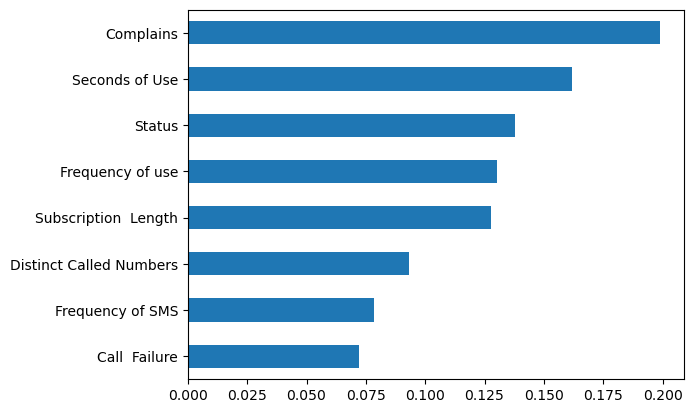

In [27]:
importance_sr = pd.Series(rf.feature_importances_, index=X.columns)
importance_sr.sort_values(ascending=True).plot.barh()
plt.show()

### Brute-force Computational Dimension Reduction

In [28]:
import itertools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV

In [29]:
in_atts = ['Call  Failure', 'Complains', 'Subscription  Length',
           'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 
           'Distinct Called Numbers', 'Status']
n_in_atts = len(in_atts)
result_df = pd.DataFrame(columns = ['subset_candidate','best_k',
                                     'performance'])
customer_df_std = (customer_df - customer_df.min())/(
                   customer_df.max()-customer_df.min())

for n in range(1,n_in_atts+1):
    for atts in itertools.combinations(in_atts, r=n):
        atts=list(atts)
        X = customer_df_std[atts]
        y = customer_df['Churn']
        
        # Tune KNN
        param_grid = {
            'n_neighbors':[1,3,5,7]}
        gridSearch = GridSearchCV(KNeighborsClassifier(),
                                param_grid, cv=2, scoring='recall')
        gridSearch.fit(X,y)
        best_k = gridSearch.best_params_['n_neighbors']
        
        # Train the tuned KNN
        knn=KNeighborsClassifier(best_k).fit(X,y)
        
        # Prediction
        y_predict = knn.predict(X)
        
        # Performance evaluation
        dic_append = {'subset_candidate':atts,
                      'best_k':best_k,
                      'performance': recall_score(y, y_predict)}
        
        # Recording and reporting
        result_df.loc[len(result_df)] = dic_append
        #print(dic_append)

In [30]:
dic_append

{'subset_candidate': ['Call  Failure',
  'Complains',
  'Subscription  Length',
  'Seconds of Use',
  'Frequency of use',
  'Frequency of SMS',
  'Distinct Called Numbers',
  'Status'],
 'best_k': 3,
 'performance': 0.9191919191919192}

In [31]:
result_df.sort_values('performance', ascending=False).head(5)

,subset_candidate,best_k,performance
62,"[Complains, Seconds of Use, Frequency of use]",1,1.00000
173,"[Call Failure, Complains, Seconds of Use, Fre...",1,0.99798
137,"[Complains, Seconds of Use, Frequency of use, ...",1,0.99798
138,"[Complains, Seconds of Use, Frequency of use, ...",1,0.99798
99,"[Call Failure, Complains, Seconds of Use, Dis...",1,0.99798


## Principal Component Analysis (PCA

In [32]:
toy_df = pd.read_excel('PCA_toy_dataset.xlsx')
toy_df.head(3)

,Dimension_1,Dimension_2
0,41,52
1,50,64
2,64,52


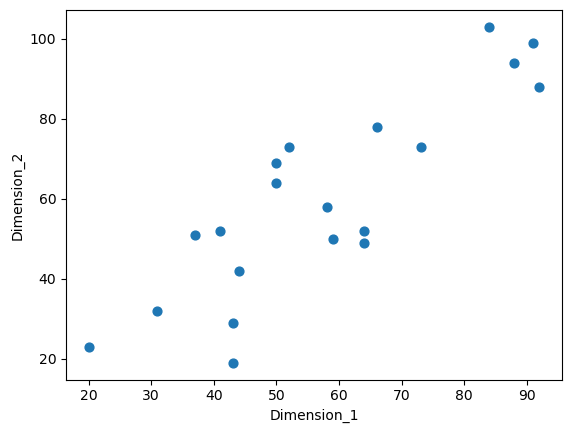

In [33]:
# Plot shows a correlation between the 2 attributes
toy_df.plot.scatter(x='Dimension_1', y='Dimension_2', s=40)
plt.show()

In [34]:
# Variance is split 40-60
var_df = pd.DataFrame(toy_df.var())
var_df.columns=['Variance']
var_df.reset_index(inplace=True)
var_df

,index,Variance
0,Dimension_1,415.315789
1,Dimension_2,611.673684


In [35]:
var_df.loc[len(var_df)] = {'index':'Total','Variance':var_df['Variance'].sum()}
var_df.set_index('index')

,Variance
index,
Dimension_1,415.315789
Dimension_2,611.673684
Total,1026.989474


In [36]:
# Dimension 1 and Dimension 2 are highly correlated
toy_df.corr()

,Dimension_1,Dimension_2
Dimension_1,1.000000,0.859195
Dimension_2,0.859195,1.000000


In [37]:
from sklearn.decomposition import PCA
pca = PCA().fit(toy_df)

toy_t_df = pd.DataFrame(pca.transform(toy_df))
toy_t_df.columns = ['PC1','PC2']
toy_t_df

,PC1,PC2
0,-16.469846,-7.962674
1,-1.476788,-8.418973
2,-2.116506,10.009016
3,-19.747457,-10.464127
4,51.457824,1.775480
5,19.447434,-4.653743
6,-41.007198,14.194004
7,50.214928,-6.190398
8,-4.460640,11.881191
9,45.678760,2.551638


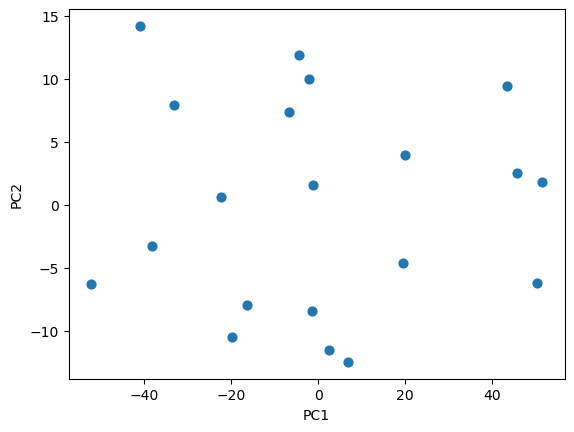

In [38]:
# PC1 and PC2 are scattered with no apparent relationship
toy_t_df.plot.scatter(x='PC1',y='PC2',s=40)
plt.show()

In [39]:
var_df = pd.DataFrame(toy_t_df.var())
var_df.columns=['Variance']
var_df.reset_index(inplace=True)
var_df

,index,Variance
0,PC1,957.537176
1,PC2,69.452298


In [40]:
# Variance has shihfted to PC1
# Variance total has not changed
var_df.loc[len(var_df)] = {'index':'Total','Variance':var_df['Variance'].sum()}
var_df.set_index('index')

,Variance
index,
PC1,957.537176
PC2,69.452298
Total,1026.989474


In [41]:
# PC1 and PC2 are not correlated
toy_t_df.corr()

,PC1,PC2
PC1,1.000000e+00,5.680543e-16
PC2,5.680543e-16,1.000000e+00


### Example – Non-parametric Dimension Reduction

In [42]:
# Load data and pivot to country as the index
report_df = pd.read_csv('WH Report_preprocessed.csv')
country_df = report_df.pivot(index='Name', columns='year',
                             values=['Life_Ladder','Log_GDP_per_capita',
                                     'Social_support','Healthy_life_expectancy_at_birth',
                                     'Freedom_to_make_life_choices',
                                     'Generosity','Perceptions_of_corruption',
                                     'Positive_affect','Negative_affect'])

In [43]:
country_df.head(3)

Life_Ladder                                                   \
year               2010   2011   2012   2013   2014   2015   2016   2017   
Name                                                                       
Afghanistan       4.758  3.832  3.783  3.572  3.131  3.983  4.220  2.662   
Albania           5.269  5.867  5.510  4.551  4.814  4.607  4.511  4.640   
Algeria           5.464  5.317  5.605  5.980  6.355  5.848  5.341  5.249   

                           ... Negative_affect                               \
year          2018   2019  ...            2010   2011   2012    2013   2014   
Name                       ...                                                
Afghanistan  2.694  2.375  ...           0.275  0.267  0.268  0.2730  0.375   
Albania      5.004  4.995  ...           0.300  0.257  0.271  0.3380  0.335   
Algeria      5.043  4.745  ...           0.255  0.255  0.230  0.2035  0.177   

                                                
year          2015   2016   2017   2018   2019  
Name                                            
Afghanistan  0.339  0.348  0.371  0.405  0.502  
Albania      0.350  0.322  0.334  0.319  0.274  
Algeria      0.277  0.377  0.289  0.293  0.215  

[3 rows x 90 columns]

In [44]:
X = country_df

# Standardize the X dataset
X = (X-X.mean())/(X.std())
X.head(3)

Life_Ladder                                                    \
year               2010      2011      2012      2013      2014      2015   
Name                                                                        
Afghanistan   -0.622104 -1.511427 -1.475323 -1.543065 -1.998271 -1.323126   
Albania       -0.190849  0.282957  0.020949 -0.744787 -0.576171 -0.772155   
Algeria       -0.026280 -0.202012  0.103257  0.420421  0.725942  0.323607   

                                                     ... Negative_affect  \
year             2016      2017      2018      2019  ...            2010   
Name                                                 ...                   
Afghanistan -1.128955 -2.567462 -2.660826 -2.784707  ...        0.435211   
Albania     -0.871862 -0.824119 -0.564109 -0.543304  ...        0.768225   
Algeria     -0.138575 -0.287367 -0.528710 -0.757178  ...        0.168800   

                                                                         \
year             2011      2012      2013      2014      2015      2016   
Name                                                                      
Afghanistan  0.251784  0.151250  0.078632  1.392257  0.846426  0.766223   
Albania      0.123794  0.188845  0.867605  0.877238  0.990833  0.452838   
Algeria      0.098196 -0.324944 -0.764963 -1.157086  0.032497  1.115768   

                                           
year             2017      2018      2019  
Name                                       
Afghanistan  1.000075  1.302003  2.385332  
Albania      0.559866  0.318447 -0.165331  
Algeria      0.024478  0.021092 -0.825371  

[3 rows x 90 columns]

In [45]:
X.var().head(3)

             year
Life_Ladder  2010    1.0
             2011    1.0
             2012    1.0
dtype: float64

In [46]:
X.std().head(3)

             year
Life_Ladder  2010    1.0
             2011    1.0
             2012    1.0
dtype: float64

In [47]:
# There are 90 columns
X.shape

(122, 90)

In [48]:
from sklearn.decomposition import PCA

In [49]:
pca=PCA().fit(X)
X_t = pd.DataFrame(pca.transform(X),index = X.index)
X_t.columns = ['PC{}'.format(i) for i in range(1,91)]

In [50]:
X_t.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28',
       'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37',
       'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46',
       'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55',
       'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64',
       'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73',
       'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81', 'PC82',
       'PC83', 'PC84', 'PC85', 'PC86', 'PC87', 'PC88', 'PC89', 'PC90'],
      dtype='object')

In [51]:
X_t.var().head()

PC1    42.983254
PC2    14.485954
PC3     6.477992
PC4     6.150161
PC5     4.761642
dtype: float64

In [52]:
total_variance = X.var().sum()
dic = {'variance_percentage':X_t.var()/total_variance,
       'cumulative_variance_percentage':
       X_t.var().cumsum()/total_variance}

explanation_df = pd.DataFrame(dic)
explanation_df


,variance_percentage,cumulative_variance_percentage
PC1,4.775917e-01,0.477592
PC2,1.609550e-01,0.638547
PC3,7.197769e-02,0.710524
PC4,6.833512e-02,0.778860
PC5,5.290713e-02,0.831767
...,...,...
PC86,4.023476e-08,1.000000
PC87,6.144899e-11,1.000000
PC88,1.264890e-31,1.000000
PC89,1.586764e-33,1.000000


<Axes: xlabel='PC1', ylabel='PC2'>

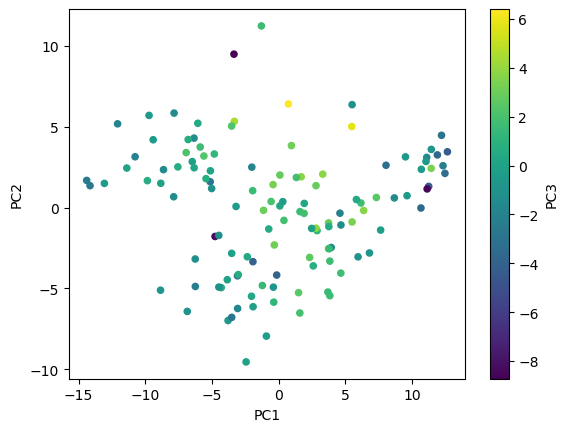

In [53]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False)

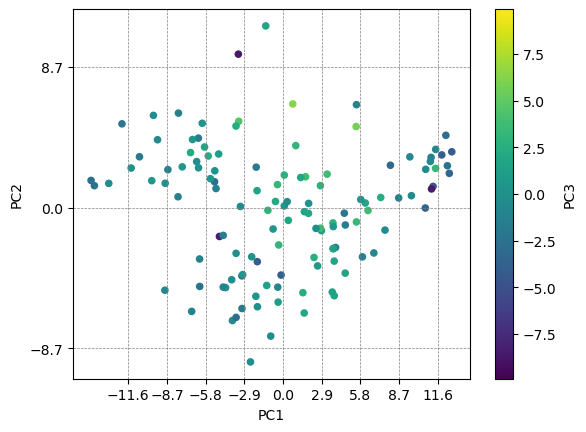

In [54]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False, 
                  vmin=-1/0.101, vmax=1/0.101)

x_ticks_vs = [-2.9*4 + 2.9*i for i in range(9)]
for v in x_ticks_vs:
    plt.axvline(v,c='gray',linestyle='--',linewidth=0.5)
plt.xticks(x_ticks_vs)

y_ticks_vs = [-8.7,0,8.7]
for v in y_ticks_vs:
    plt.axhline(v,c='gray',linestyle='--',linewidth=0.5)
plt.yticks(y_ticks_vs)
plt.show()

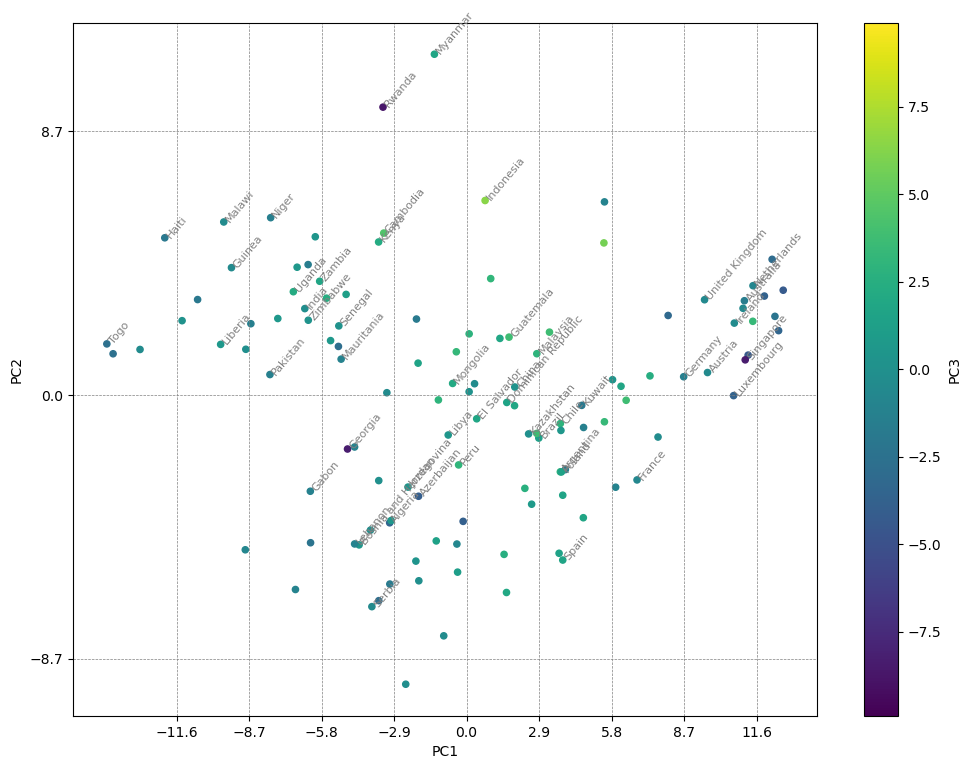

In [55]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False, 
                  vmin=-1/0.101, vmax=1/0.101,
                  figsize=(12,9))

x_ticks_vs = [-2.9*4 + 2.9*i for i in range(9)]
for v in x_ticks_vs:
    plt.axvline(v,c='gray',linestyle='--',linewidth=0.5)
plt.xticks(x_ticks_vs)

y_ticks_vs = [-8.7,0,8.7]
for v in y_ticks_vs:
    plt.axhline(v,c='gray',linestyle='--',linewidth=0.5)
plt.yticks(y_ticks_vs)

for i, row in X_t.sample(50).iterrows():
    plt.annotate(i, (row.PC1, row.PC2),
                 rotation=50,c='gray',size=8)
plt.show()

### Functional Data Analysis
#### Example - Parametric Dimension Reduction

In [56]:
# Create list of happiness index values
happiness_index = ['Life_Ladder','Log_GDP_per_capita','Social_support',
                   'Healthy_life_expectancy_at_birth',
                   'Freedom_to_make_life_choices','Generosity',
                   'Perceptions_of_corruption','Positive_affect',
                   'Negative_affect']

In [57]:
# Display the first row
country_df[:1]

Life_Ladder                                                  \
year               2010   2011   2012   2013   2014   2015  2016   2017   
Name                                                                      
Afghanistan       4.758  3.832  3.783  3.572  3.131  3.983  4.22  2.662   

                           ... Negative_affect                              \
year          2018   2019  ...            2010   2011   2012   2013   2014   
Name                       ...                                               
Afghanistan  2.694  2.375  ...           0.275  0.267  0.268  0.273  0.375   

                                                
year          2015   2016   2017   2018   2019  
Name                                            
Afghanistan  0.339  0.348  0.371  0.405  0.502  

[1 rows x 90 columns]

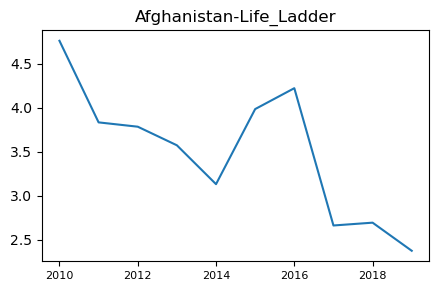

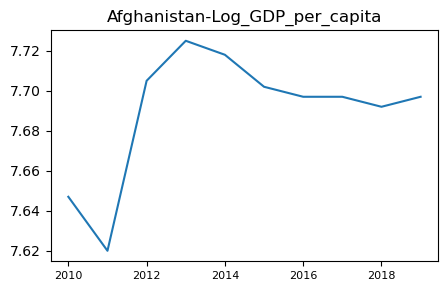

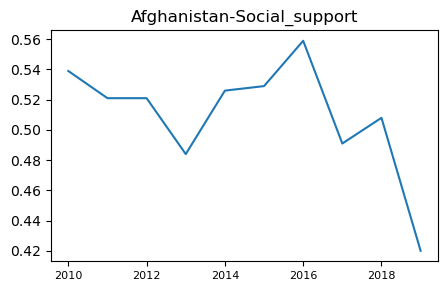

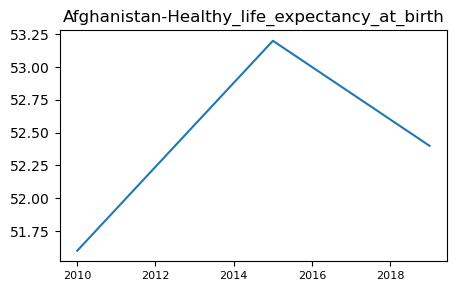

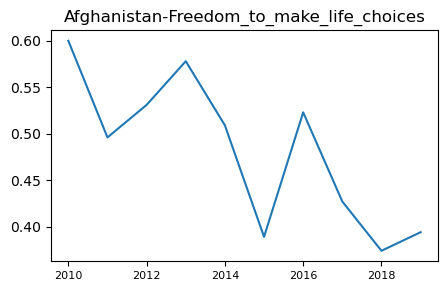

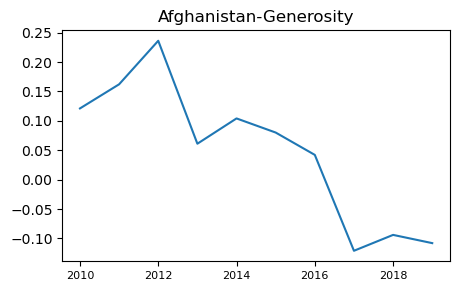

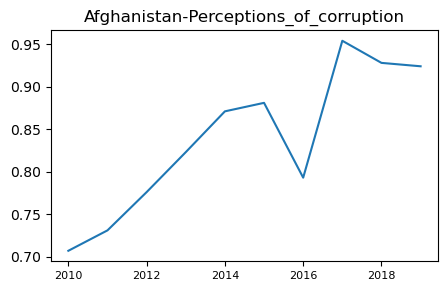

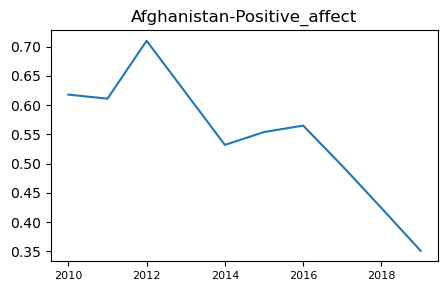

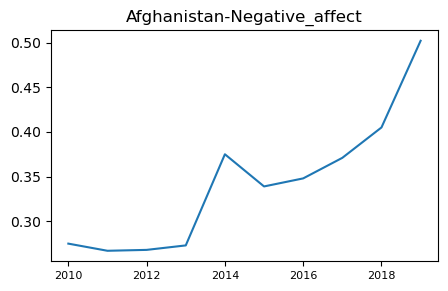

In [68]:
# Only create the plots for Afghanistan by each happiness index value
for i, row in country_df[:1].iterrows():
    for h_i in happiness_index:
        plt.figure(figsize=(5,3))
        plt.plot(row[h_i])
        plt.xticks(fontsize=8)
        plt.title(f'{i}-{h_i}')
        plt.show()

In [69]:
# Create a linear function that returns the y target value
def linearfunction(t,a,b):
    y = a + b*t
    return y

In [70]:
# Set the x and y arrays
x_data = range(10)
y_data = country_df.loc['Afghanistan','Life_Ladder']

In [71]:
# Fit the linear function to the x and y data
from  scipy.optimize import curve_fit
p,c = curve_fit(linearfunction, x_data, y_data)

In [72]:
# Return the intercept and coefficient
p

array([ 4.37978182, -0.19528485])

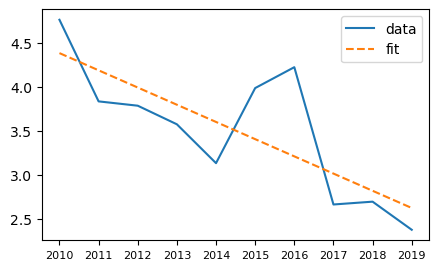

In [73]:
# Plot a line of the original data then plot a linear line based on predicted values
# for the Afghanistan Life Ladder happiness index
fit_y = linearfunction(x_data, p[0], p[1])
plt.figure(figsize=(5,3))
plt.plot(x_data, y_data, label='data')
plt.plot(x_data, fit_y, '--', label='fit')
plt.xticks(x_data, y_data.index, fontsize=8)
plt.legend()
plt.show()

In [74]:
# Print the r-squared value for the actual vs predicted y values
from sklearn.metrics import r2_score
print("r2_score:", r2_score(y_data, fit_y))

r2_score: 0.5954935497933329


In [75]:
# Create an empy dataframe where the countries are the index values and columns are the
# happiness index values
r_Squared_df = pd.DataFrame(index=country_df.index, columns=happiness_index)

In [76]:
# Display the first 3 rows
r_Squared_df.head(3)

,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
Name,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


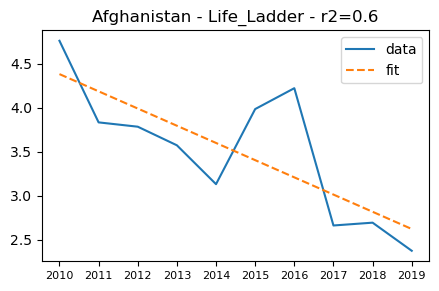

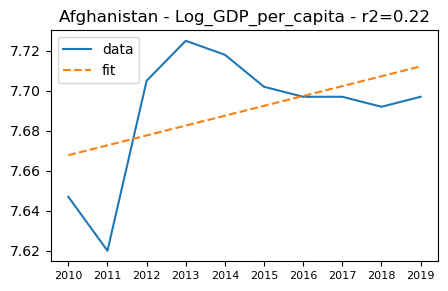

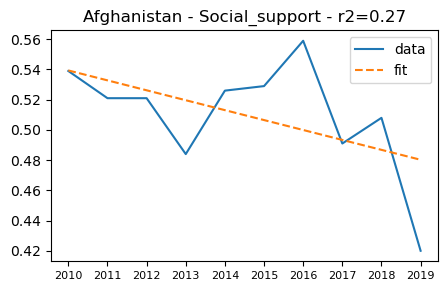

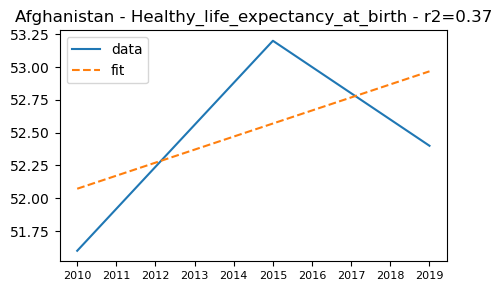

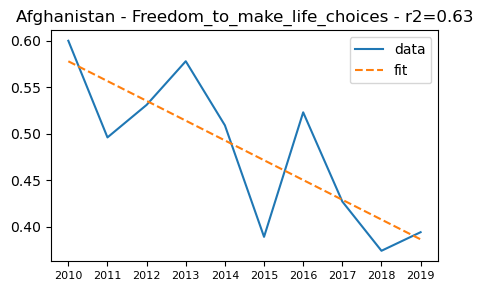

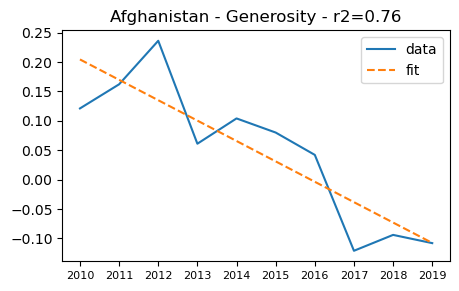

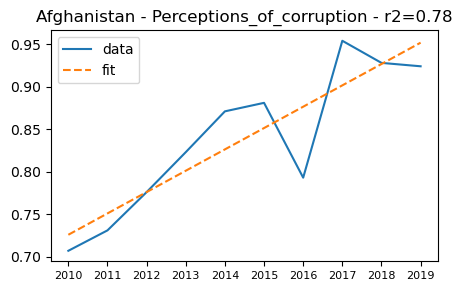

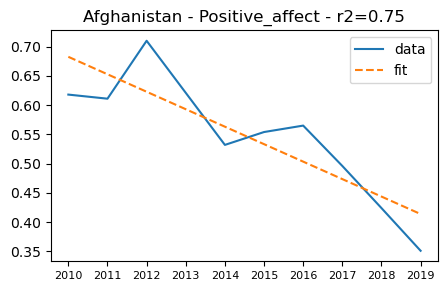

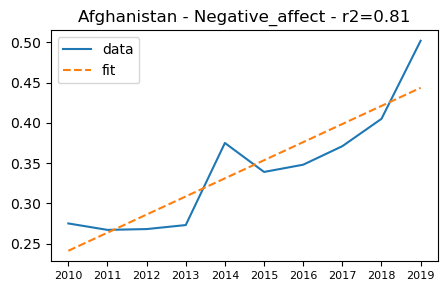

In [78]:
# Combine the FDA process and plotting processes
# Show the linear regression lines for the happiness index values for Afghanistan
for i, row in country_df[:1].iterrows():
    for h_i in happiness_index:
        x_data = range(10)
        y_data = row[h_i]
        p,c = curve_fit(linearfunction, x_data, y_data)
        fit_y = linearfunction(x_data, p[0], p[1])
        rS = r2_score(y_data, fit_y)
        r_Squared_df.at[i,h_i] = rS
        plt.figure(figsize=(5,3))
        plt.plot(x_data, y_data, label='data')
        plt.plot(x_data, fit_y, '--', label='fit')
        plt.xticks(x_data, y_data.index, fontsize=8)
        plt.legend()
        plt.title(f'{i} - {h_i} - r2={str(round(rS,2))}')
        plt.show()

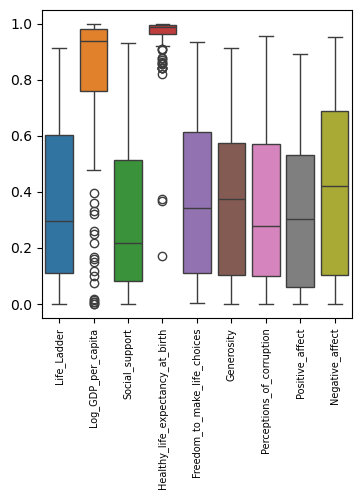

In [82]:
# Create the a,b linear regression values for all countries and all happiness index values
# a,b are the y = a + bx values
# Determine the fitted y values bsed on the the linear functions
# Create a boxplot for all the happiness index values of the countries
for i, row in country_df.iterrows():
    for h_i in happiness_index:
        x_data = range(10)
        y_data = row[h_i]
        p,c = curve_fit(linearfunction, x_data, y_data)
        fit_y = linearfunction(x_data, p[0], p[1])
        rS = r2_score(y_data, fit_y)
        r_Squared_df.at[i,h_i] = rS

plt.figure(figsize=(4,4))
sns.boxplot(data=r_Squared_df)
plt.xticks(rotation=90, fontsize=7)
plt.show()

In [135]:
# Create a multi level index of the happiness index and a.b values
ml_index = pd.MultiIndex.from_product(
    [happiness_index, ['a','b']],
    names=('Happiness Index', 'Paramter'))

In [136]:
# Display the index
ml_index

MultiIndex([(                     'Life_Ladder', 'a'),
            (                     'Life_Ladder', 'b'),
            (              'Log_GDP_per_capita', 'a'),
            (              'Log_GDP_per_capita', 'b'),
            (                  'Social_support', 'a'),
            (                  'Social_support', 'b'),
            ('Healthy_life_expectancy_at_birth', 'a'),
            ('Healthy_life_expectancy_at_birth', 'b'),
            (    'Freedom_to_make_life_choices', 'a'),
            (    'Freedom_to_make_life_choices', 'b'),
            (                      'Generosity', 'a'),
            (                      'Generosity', 'b'),
            (       'Perceptions_of_corruption', 'a'),
            (       'Perceptions_of_corruption', 'b'),
            (                 'Positive_affect', 'a'),
            (                 'Positive_affect', 'b'),
            (                 'Negative_affect', 'a'),
            (                 'Negative_affect', 'b')],
         

In [143]:
# Create function to perform a linear FDA
def linearFDA(row):
    output_sr = pd.Series(np.nan, index=ml_index)
    for h_i in happiness_index:
        x_data = range(10)
        y_data = row[h_i]
        p,c = curve_fit(linearfunction, x_data, y_data, maxfev=1000)
        output_sr.loc[(h_i, 'a')] = p[0]
        output_sr.loc[(h_i, 'b')] = p[1]
    return(output_sr)

In [144]:
# Create a new dataset by applying the linearFDA function to the original data
country_df_t = country_df.apply(linearFDA, axis=1)

In [146]:
# Display the first 3 rows
country_df_t.head(3)

Happiness Index Life_Ladder           Log_GDP_per_capita            \
Paramter                  a         b                  a         b   
Name                                                                 
Afghanistan        4.379782 -0.195285           7.667800  0.004933   
Albania            5.336364 -0.079903           9.290091  0.026558   
Algeria            5.838145 -0.076321           9.298818  0.006985   

Happiness Index Social_support           Healthy_life_expectancy_at_birth  \
Paramter                     a         b                                a   
Name                                                                        
Afghanistan           0.539364 -0.006570                        52.072727   
Albania               0.750145 -0.012321                        66.381818   
Algeria               0.820327 -0.003473                        64.465091   

Happiness Index           Freedom_to_make_life_choices           Generosity  \
Paramter                b                            a         b          a   
Name                                                                          
Afghanistan      0.099394                     0.577909 -0.021291   0.204273   
Albania          0.288485                     0.538255  0.031721  -0.176836   
Algeria          0.177091                     0.585873 -0.015461  -0.213582   

Happiness Index           Perceptions_of_corruption           Positive_affect  \
Paramter                b                         a         b               a   
Name                                                                            
Afghanistan     -0.034661                  0.725836  0.025103        0.682600   
Albania          0.018964                  0.809873  0.012739        0.626582   
Algeria          0.013152                  0.637400  0.012267        0.580909   

Happiness Index           Negative_affect            
Paramter                b               a         b  
Name                                                 
Afghanistan     -0.029867        0.241036  0.022503  
Albania          0.008048        0.296855  0.002921  
Algeria          0.005742        0.234745  0.004979

#### Exponential FDA Function

In [201]:
# Diaply the value of e
np.exp(1)

2.718281828459045

In [202]:
# Create an exponential function
def exponential(x, a, b):
    y = a*np.exp(b*x)
    return y

In [203]:
# Load the GoogleStock csv file and display the first 3 rows
price_df = pd.read_csv('GoogleStock.csv')
price_df.head(3)

,t,Price
0,2004-08-19,50.2162
1,2004-08-20,54.2075
2,2004-08-23,54.7531


In [204]:
# Set the index to the 't' column
price_df.set_index('t',inplace=True)

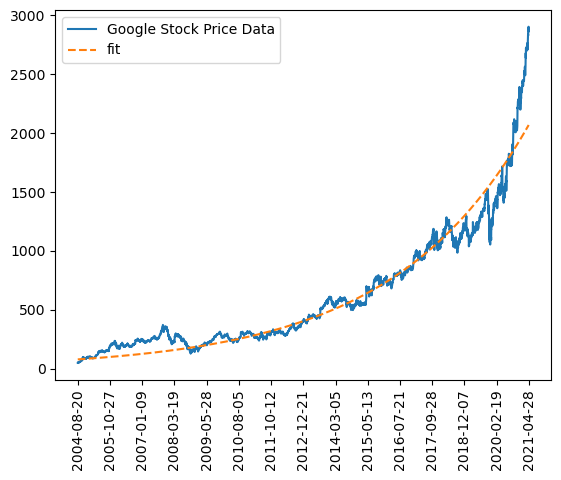

r2_score: 0.9448509203130193


In [205]:
# Create the x and y arrays
y_data = price_df['Price']
x_data = range(len(y_data))

# Fit the x and y data to the exponential function using curve_fit
p,c = curve_fit(exponential, x_data, y_data, p0=[50,0])

# Predict the fit_y values using the exponential function and intercept and coefficient
fit_y = exponential(x_data, p[0], p[1])

# PLot the predicted results (fit_y) against the actual data
plt.plot(x_data, y_data, label='Google Stock Price Data')
plt.plot(x_data, fit_y, '--', label='fit')
plt.xticks(np.linspace(1, len(y_data), 15), y_data.iloc[1::300].index,rotation=90)
plt.legend()
plt.show()

# Print the r2 score
print("r2_score:", r2_score(y_data, fit_y))

#### Fourier FDA Function

In [215]:
# Create a fourier function
def fourier(x, a0, a1, b1, w):
    y = a0 + a1*np.cos(x*w) + b1*np.sin(x*w)
    return y

In [216]:
# Load the noise data, set the index value to the column 't', and display the first 3 rows
noise_df = pd.read_csv('Noise_data.csv')
noise_df.set_index('t',inplace=True)
noise_df.head(3)

,Signal
t,
1,605.340308
2,267.958658
3,304.652019


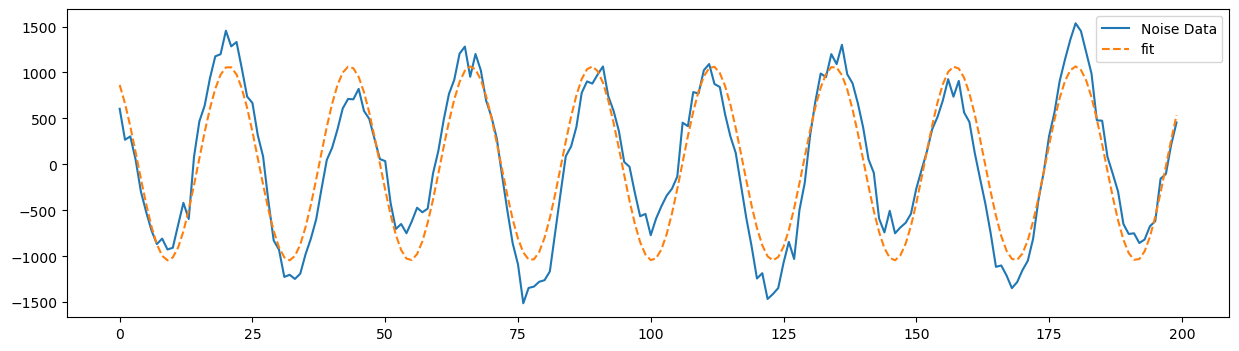

r2_score: 0.8770501065480367


In [217]:
# Create the x and y arrays
y_data = noise_df.Signal
x_data = range(len(y_data))

# Fit the x and y data to the fourier function using curve_fit
p,c = curve_fit(fourier, x_data, y_data, p0=[10,1000,-400,0.3])

# Predict the fit_y values using the fourier function and intercept and coefficient
fit_y = fourier(x_data, p[0], p[1], p[2], p[3])

# PLot the predicted results (fit_y) against the actual data
plt.figure(figsize=(15,4))
plt.plot(x_data, y_data, label='Noise Data')
plt.plot(x_data, fit_y, '--', label='fit')
plt.legend()
plt.show()

# Print the r2 score
print("r2_score:", r2_score(y_data, fit_y))

#### Sinusoidal Function

In [218]:
# Create a sinusoidal function
def sinusoidal(x, a1, b1, c1):
    y = a1*np.sin(b1*x+c1)
    return y

In [219]:
# Load the noise data, set the index value to the column 't', and display the first 3 rows
noise_df = pd.read_csv('Noise_data.csv')
noise_df.set_index('t',inplace=True)
noise_df.head(3)

,Signal
t,
1,605.340308
2,267.958658
3,304.652019


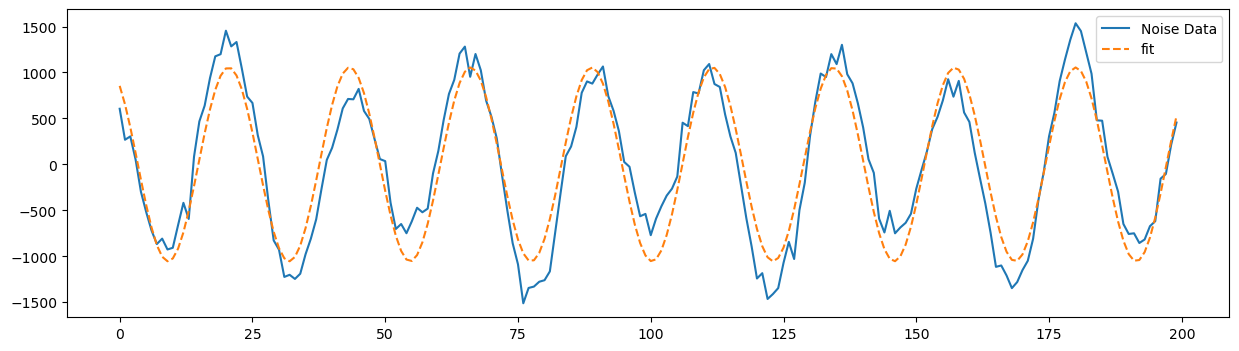

r2_score: 0.8768630893287548


In [220]:
# Create the x and y arrays
y_data = noise_df.Signal
x_data = range(len(y_data))

# Fit the x and y data to the sinusoidal function using curve_fit
p,c = curve_fit(sinusoidal, x_data, y_data, p0=[1000,0.25, 2.5])

# Predict the fit_y values using the sinusoidal function and intercept and coefficient
fit_y = sinusoidal(x_data, p[0], p[1], p[2])

# PLot the predicted results (fit_y) against the actual data
plt.figure(figsize=(15,4))
plt.plot(x_data, y_data, label='Noise Data')
plt.plot(x_data, fit_y, '--', label='fit')
plt.legend()
plt.show()

# Print the r2 score
print("r2_score:", r2_score(y_data, fit_y))

#### Gaussian Function

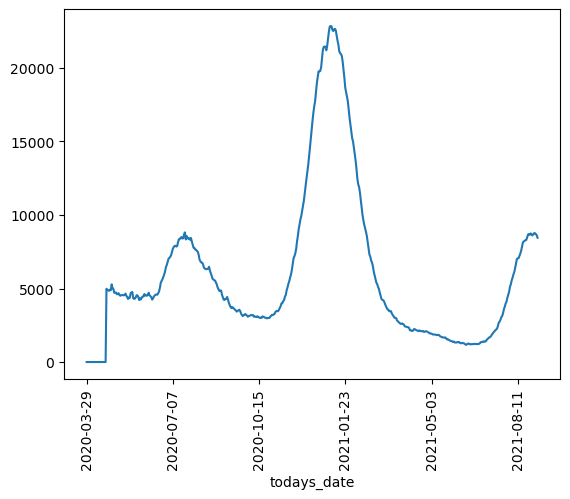

In [221]:
# Laod the covid 19 hospital data
covid_county_day_df = pd.read_csv('covid19hospitalbycounty.csv')

#Group the data by date and sum
covid_day_df = covid_county_day_df.groupby('todays_date').hospitalized_covid_patients.sum()

# PLot the data
covid_day_df.plot()
plt.xticks(rotation=90)
plt.show()

In [222]:
# Create the gaussian function
def gaussian(x,a1,b1,c1):
    y= a1*np.exp(-((x-b1)**2/2*c1**2))
    return y

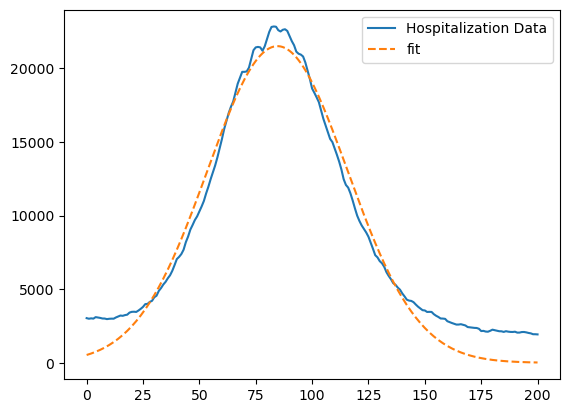

r2_score: 0.9668373070226166


In [224]:
# Create the x and y arrays
y_data = covid_day_df.loc['2020-10-15':'2021-05-03']
x_data = range(len(y_data))

# Fit the x and y data to the gaussian function using curve_fit
p,c = curve_fit(gaussian, x_data, y_data)

# Predict the fit_y values using the gaussian function and intercept and coefficient
fit_y = gaussian(x_data, p[0], p[1], p[2])

# PLot the data
plt.plot(x_data, y_data, label='Hospitalization Data')
plt.plot(x_data, fit_y, '--', label='fit')
plt.legend()
plt.show()

# Print the r2 score
print("r2_score:", r2_score(y_data, fit_y))